<a href="https://colab.research.google.com/github/jojoadv77-sketch/SDP2_code/blob/main/cyberbullying_detection_13_3_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyberbullying Detection using BERTweet
This notebook trains a BERTweet model to classify tweets into 6 categories:
- not_cyberbullying
- gender
- religion
- other_cyberbullying
- age
- ethnicity

## Cell 1: Install and Import Libraries

In [ ]:

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import json
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda:0


###Cell 1.5 :Emoji2vec files


In [ ]:
!pip install transformers torch emoji pandas scikit-learn seaborn matplotlib -q
!pip install gensim -q  # gensim loads emoji2vec
# Download pretrained emoji2vec embeddings
!wget -q https://github.com/uclnlp/emoji2vec/raw/master/pre-trained/emoji2vec.bin
import gensim
# Load emoji2vec
e2v = gensim.models.KeyedVectors.load_word2vec_format('emoji2vec.bin', binary=True)
print(f"✅ emoji2vec loaded! Vocabulary size: {len(e2v)} emojis")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.7 MB/s eta 0:00:00
✅ emoji2vec loaded! Vocabulary size: 1661 emojis


###Cell 1.6: EmojiEncoder Class for DAM

In [ ]:
class EmojiEncoder(nn.Module): # declaring the class in a pytorch module

    def __init__(self, e2v, embed_dim=300):  #Constructor takes the loaded emoji2vec model (e2v) and embedding size (300 because emoji2vec vectors are 300-dimensional).

        super(EmojiEncoder, self).__init__()

       # Stores them so the whole class can access them.
        self.e2v = e2v
        self.embed_dim = embed_dim

        # . We need 768 because BERTweet outputs 768, and DAM needs both inputs to be the same size to fuse them.
        self.projection = nn.Linear(embed_dim, 768)

        #Activation function — adds non-linearity so the projection isn't just a flat transformation.
        self.relu = nn.ReLU()

    #Takes a batch of emoji vectors → projects to 768 → applies ReLU → returns it ready for DAM.
    def forward(self, emoji_vectors):

        # emoji_vectors shape: (batch_size, 300)
        out = self.projection(emoji_vectors)  # → (batch_size, 768)
        return self.relu(out)

 #a helper function , takes the emojis from one tweet
def get_emoji_vector(emoji_list, e2v, embed_dim=300):

    #Loops through each emoji, checks if emoji2vec knows it, and if yes grabs its 300-dim vector. Unknown emojis are skipped.
    vectors = []
    for e in emoji_list:

        if e in e2v: #With this check — unknown emojis are just silently skipped, and you average only the ones that were recognized.
            vectors.append(e2v[e])
    if vectors:  # If the tweet HAD emojis, average all their vectors into one single 300-dim vector representing the overall emoji meaning of the tweet.
        return np.mean(vectors, axis=0).astype(np.float32)
    else:
        # Tweet has no emojis → return zero vector
        return np.zeros(embed_dim, dtype=np.float32)


  # quick test
test = get_emoji_vector(['😊', '🤮'], e2v)
print(f"Emoji vector shape: {test.shape}")  # Should print (300,)
print(f"All zeros? {np.all(test == 0)}")    # Should print False

#q:why are we printing 300 dim but we said BERTtweet needs 768 outputs ?
#Ans: get_emoji_vector → 300-dim  ← what you just tested
#       ↓
#EmojiEncoder.projection (Linear 300→768)
#       ↓
 #   768-dim  ← what DAM receives

Emoji vector shape: (300,)
All zeros? False


## Cell 2: Load Dataset

In [ ]:
from google.colab import files
import io

print("Upload cyberbullying_tweets.csv:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"✅ Loaded {len(df)} rows")
print(df.head())

Upload cyberbullying_tweets.csv:


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv
✅ Loaded 47692 rows
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


## Cell 3: Preprocess Text
- Converts emojis to text (e.g. 😊 becomes 'smiling face')
- Replaces URLs with HTTPURL token
- Replaces @mentions with @USER token
- These normalizations match how BERTweet was originally trained

In [ ]:
USE_EMOJIS = True

def process_text(text):
    text = str(text)
    # Convert emojis to text e.g. 😊 becomes 'smiling face'
    if USE_EMOJIS:
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = text.replace("_", " ").replace(":", "")
    else:
        text = emoji.replace_emoji(text, replace='')
    # Normalize URLs and mentions for BERTweet
    text = re.sub(r"http\S+|www\S+|https\S+", 'HTTPURL', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '@USER', text)
    return re.sub(r'\s+', ' ', text).strip()

# "For every tweet, scan it for emojis and store them as a list in a new column called emojis before preprocessing destroys them."
df['emojis'] = df['tweet_text'].apply(lambda x: [e['emoji'] for e in emoji.emoji_list(str(x))])

#This is the existing line — runs process_text() on every tweet which converts emojis to text and normalizes URLs/mentions.
df['content'] = df['tweet_text'].apply(process_text)

print("✅ Text preprocessed")
print(df['content'].head())

#  verify emojis extracted
print("\nEmoji extraction sample:")
print(df[['tweet_text', 'emojis']].head(15))

print("\n")







# Test emoji extraction is working
test_tweets = [
    "You are so stupid because of your religion 🕌",
    "Have a great day everyone! 😊🎉",
    "People of that race are all the same 🤮",
]
print("\n")
for tweet in test_tweets:
    emojis = [e['emoji'] for e in emoji.emoji_list(str(tweet))]
    print(f"Tweet: {tweet}")
    print(f"Emojis found: {emojis}")
    print(f"Vector shape: {get_emoji_vector(emojis, e2v).shape}")
    print("-" * 40)

✅ Text preprocessed
0    In other words #katandandre, your food was cra...
1    Why is #aussietv so white? #MKR #theblock #ImA...
2    @USER a classy whore? Or more red velvet cupca...
3    @USER Gio meh. P thanks for the heads up, but ...
4    @USER This is an ISIS account pretending to be...
Name: content, dtype: object

Emoji extraction sample:
                                           tweet_text emojis
0   In other words #katandandre, your food was cra...     []
1   Why is #aussietv so white? #MKR #theblock #ImA...     []
2   @XochitlSuckkks a classy whore? Or more red ve...     []
3   @Jason_Gio meh. :P  thanks for the heads up, b...     []
4   @RudhoeEnglish This is an ISIS account pretend...     []
5   @Raja5aab @Quickieleaks Yes, the test of god i...     []
6   Itu sekolah ya bukan tempat bully! Ga jauh kay...     []
7   Karma. I hope it bites Kat on the butt. She is...     []
8        @stockputout everything but mostly my priest     []
9   Rebecca Black Drops Out of School Du

## Cell 4: Create Labels and Split Data
- Maps text labels to numbers (e.g. 'religion' -> 0, 'gender' -> 1)
- Splits data into 90% train, 5% validation, 5% test

In [ ]:
# Map text labels to numbers
class_names = df['cyberbullying_type'].unique()
label_map = {name: i for i, name in enumerate(class_names)}
df['sentiment'] = df['cyberbullying_type'].map(label_map)

print("Classes:", class_names)
print("Label map:", label_map)
print("\nClass distribution:")
print(df['cyberbullying_type'].value_counts())

# Split into train (90%), val (5%), test (5%)
RANDOM_SEED = 42
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

print(f"\nTrain: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Classes: ['not_cyberbullying' 'gender' 'religion' 'other_cyberbullying' 'age'
 'ethnicity']
Label map: {'not_cyberbullying': 0, 'gender': 1, 'religion': 2, 'other_cyberbullying': 3, 'age': 4, 'ethnicity': 5}

Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

Train: 42922, Val: 2385, Test: 2385


## Cell 5: Load BERTweet Tokenizer
BERTweet is a BERT model pre-trained on 850M English tweets

In [ ]:
PRE_TRAINED_MODEL_NAME = 'vinai/bertweet-base'
tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME, use_fast=False)
print("✅ BERTweet tokenizer loaded!")

✅ BERTweet tokenizer loaded!


## Cell 6: Dataset and DataLoader
- SentimentDataset converts raw text into tokenized tensors for the model
- DataLoader batches the data for efficient training

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, reviews, targets, tokenizer, max_len, emoji_vectors):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.emoji_vectors = emoji_vectors #the updated

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]
        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long),
            'emoji_vector': torch.tensor(self.emoji_vectors[item], dtype=torch.float) # this also
        }

BATCH_SIZE = 32
MAX_LEN = 128
#ANALYSIS of LINE 1000 and its almost the same to the 2 below it

#df_train['emojis'].tolist() → converts the emojis column of the training set into a Python list, so each item is like ['😊', '🤮']
#for e in ... → loops through every tweet's emoji list
#get_emoji_vector(e, e2v) → converts each emoji list into a 300-dim vector
#np.array([...]) → stacks all those individual vectors into one big array of shape
# 42922 rows: that's how many training tweets you have)   , 300 columns → the 300 numbers that represent the emoji meaning of that tweet

train_emoji_vectors = np.array([get_emoji_vector(e, e2v) for e in df_train['emojis'].tolist()]) # THIS IS LINE 1000
val_emoji_vectors = np.array([get_emoji_vector(e, e2v) for e in df_val['emojis'].tolist()])
test_emoji_vectors = np.array([get_emoji_vector(e, e2v) for e in df_test['emojis'].tolist()])

#ANALYSIS FOR LINE 2000, SAME WAY FOR THE OTHERS UNDER IT

#df_train['content'].to_numpy() → all the cleaned tweet texts
#df_train['sentiment'].to_numpy() → all the labels (0-5)
#tokenizer → the BERTweet tokenizer to convert text to input_ids
#MAX_LEN → max 128 tokens per tweet
#train_emoji_vectors → the precomputed emoji vectors we just added

train_data_loader = DataLoader( #LINE 2000
    SentimentDataset(df_train['content'].to_numpy(), df_train['sentiment'].to_numpy(), tokenizer, MAX_LEN, train_emoji_vectors),
    batch_size=BATCH_SIZE, num_workers=0
)
val_data_loader = DataLoader(
    SentimentDataset(df_val['content'].to_numpy(), df_val['sentiment'].to_numpy(), tokenizer, MAX_LEN, val_emoji_vectors),
    batch_size=BATCH_SIZE, num_workers=0
)
test_data_loader = DataLoader(
    SentimentDataset(df_test['content'].to_numpy(), df_test['sentiment'].to_numpy(), tokenizer, MAX_LEN, test_emoji_vectors),
    batch_size=BATCH_SIZE, num_workers=0
)
print("✅ DataLoaders ready!")

✅ DataLoaders ready!


## Cell 7: Model Architecture
- Uses BERTweet as the base model
- Adds a Dropout layer to prevent overfitting
- Adds a linear layer to output 6 class scores
- Softmax converts scores to probabilities

In [ ]:
class SentimentClassifier(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        output = self.drop(pooled_output)
        output = self.out(output)
        return self.softmax(output)

model = SentimentClassifier(len(class_names))
model = model.to(device)
print("✅ Model ready!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model ready!


## Cell 8: Training Setup
- AdamW optimizer with learning rate 2e-5 (standard for fine-tuning BERT)
- Linear scheduler gradually reduces learning rate during training
- CrossEntropyLoss is used for multi-class classification

In [ ]:
EPOCHS = 4
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
loss_fn = nn.CrossEntropyLoss().to(device)
print("✅ Training setup ready!")

✅ Training setup ready!


## Cell 9: Train and Evaluate Functions

In [ ]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model.train()
    losses = []
    correct_predictions = 0
    for d in data_loader:
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        targets = d['targets'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model.eval()
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for d in data_loader:
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets = d['targets'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())
    return correct_predictions.double() / n_examples, np.mean(losses)

print("✅ Functions ready!")

✅ Functions ready!


## Cell 10: Training Loop
- Trains for 4 epochs
- Saves the best model based on validation accuracy

In [ ]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)
    train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, device, scheduler, len(df_train))
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    val_acc, val_loss = eval_model(model, val_data_loader, loss_fn, device, len(df_val))
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()
    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

# Save class names for later use
with open('class_names.json', 'w') as f:
    json.dump(list(class_names), f)

print(f"✅ Training done! Best accuracy: {best_accuracy:.4f}")
print("✅ Model and class names saved!")

Epoch 1/4
----------
Train loss 1.2485 accuracy 0.8135
Val   loss 1.1890 accuracy 0.8549

Epoch 2/4
----------
Train loss 1.1792 accuracy 0.8652
Val   loss 1.1876 accuracy 0.8541

Epoch 3/4
----------
Train loss 1.1648 accuracy 0.8789
Val   loss 1.1784 accuracy 0.8633

Epoch 4/4
----------
Train loss 1.1538 accuracy 0.8899
Val   loss 1.1788 accuracy 0.8642

✅ Training done! Best accuracy: 0.8642
✅ Model and class names saved!


## Cell 11: Plot Training History

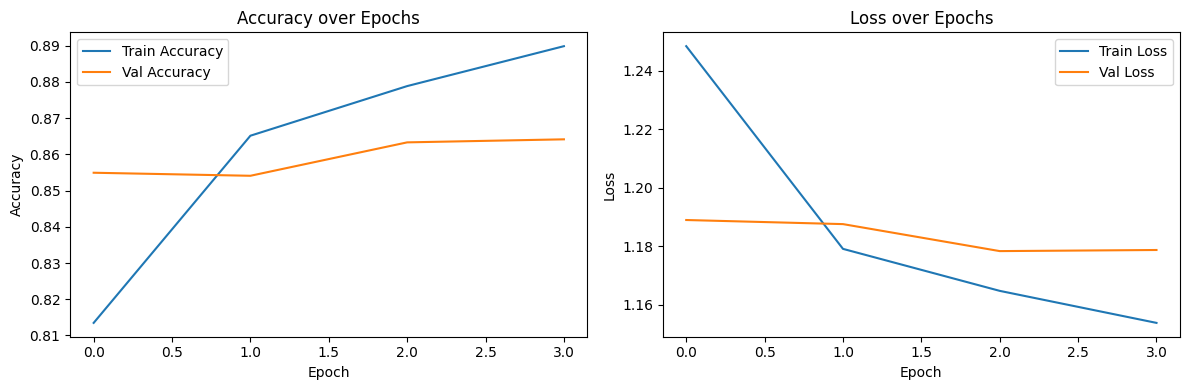

In [ ]:
# Convert tensors to float for plotting
train_acc = [x.item() if hasattr(x, 'item') else x for x in history['train_acc']]
val_acc = [x.item() if hasattr(x, 'item') else x for x in history['val_acc']]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Cell 12: Confusion Matrix
Shows how well the model classifies each category

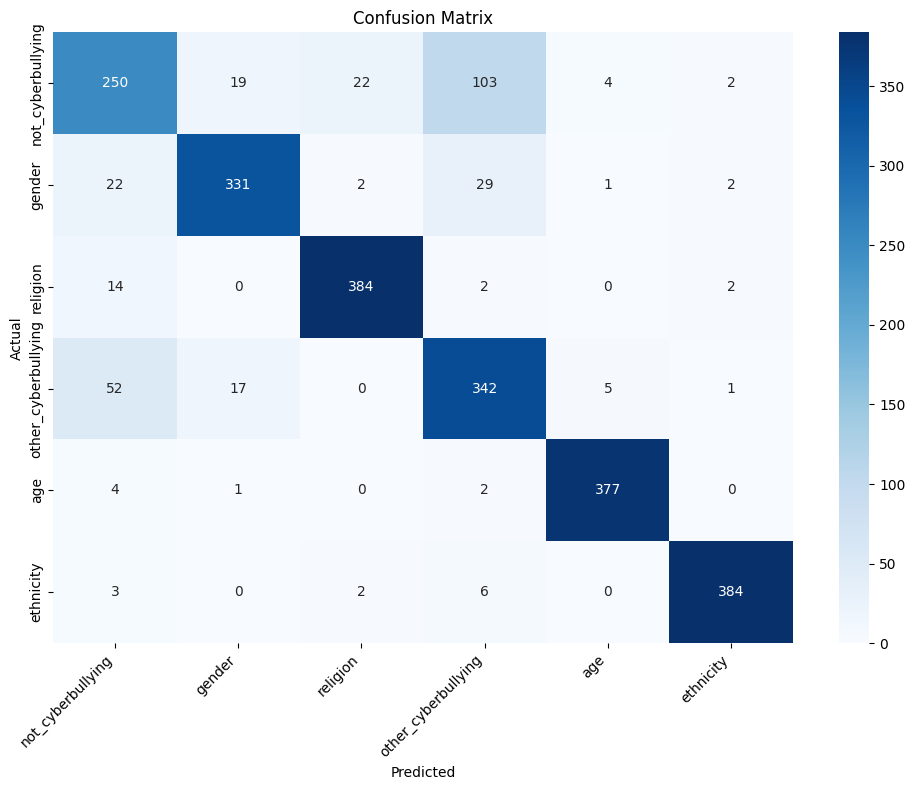


Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying       0.72      0.62      0.67       400
             gender       0.90      0.86      0.88       387
           religion       0.94      0.96      0.95       402
other_cyberbullying       0.71      0.82      0.76       417
                age       0.97      0.98      0.98       384
          ethnicity       0.98      0.97      0.98       395

           accuracy                           0.87      2385
          macro avg       0.87      0.87      0.87      2385
       weighted avg       0.87      0.87      0.87      2385



In [ ]:
def get_predictions(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for d in data_loader:
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets = d['targets'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

preds, labels = get_predictions(model, test_data_loader)

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))

## Cell 13: Classify New Sentences
Test the model on your own sentences

In [ ]:
def classify_text(text):
    text = process_text(text)
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        output = model(input_ids=input_ids, attention_mask=attention_mask)
    _, prediction = torch.max(output, dim=1)
    label = class_names[prediction.item()]
    confidence = output[0][prediction.item()].item()
    return label, confidence

# Test sentences
test_sentences = [
    "You are so stupid because of your religion 🕌",
    "Have a great day everyone! 😊🎉",
    "People of that race are all the same 🤮",
    "Happy birthday! Hope you have a wonderful day 🎂🎈",
    "You are too old to be doing this 👴",
    "Go back to your country 🖕",
    "Love and respect for all ❤️🌍",
    "Your gender makes you worthless 🤡",
]

print("=" * 60)
for sentence in test_sentences:
    label, confidence = classify_text(sentence)
    print(f"Text:       {sentence}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 60)

Text:       You are so stupid because of your religion 🕌
Prediction: religion
Confidence: 99.98%
------------------------------------------------------------
Text:       Have a great day everyone! 😊🎉
Prediction: not_cyberbullying
Confidence: 99.96%
------------------------------------------------------------
Text:       People of that race are all the same 🤮
Prediction: other_cyberbullying
Confidence: 98.95%
------------------------------------------------------------
Text:       Happy birthday! Hope you have a wonderful day 🎂🎈
Prediction: not_cyberbullying
Confidence: 99.95%
------------------------------------------------------------
Text:       You are too old to be doing this 👴
Prediction: not_cyberbullying
Confidence: 98.61%
------------------------------------------------------------
Text:       Go back to your country 🖕
Prediction: not_cyberbullying
Confidence: 99.68%
------------------------------------------------------------
Text:       Love and respect for all ❤️🌍
Prediction